In [5]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader,
)

In [6]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

In [7]:
X = np.load(
    DATA_PROCESSED / "X_windows.npy"
)

sample_dates = np.load(
    DATA_PROCESSED / "sample_dates.npy",
    allow_pickle=True
)

sample_tickers = np.load(
    DATA_PROCESSED / "sample_tickers.npy",
    allow_pickle=True
)

returns = pd.read_parquet(
    DATA_PROCESSED / "returns.parquet"
)

In [8]:
sample_dates = pd.to_datetime(sample_dates)

returns.index = pd.to_datetime(
    returns.index
)

X.shape

(70080, 60, 6)

In [9]:
WINDOW = 60

HORIZON = 10

LATENT_DIM = 8

N_EPOCHS = 50
PATIENCE = 10

BETA = 1e-3
GAMMA = 0.1

TRAIN_RATIO = 0.7
VAL_RATIO = 0.8

SEEDS = list(range(20))

In [10]:
future_returns = pd.DataFrame(
    0.0,
    index=returns.index,
    columns=returns.columns
)

for h in range(1, HORIZON + 1):
    future_returns += returns.shift(-h)

In [11]:
y = []

for date, ticker in zip(
    sample_dates,
    sample_tickers
):
    try:
        y.append(
            future_returns.loc[date, ticker]
        )
    except:
        y.append(np.nan)

y = np.array(y)

In [12]:
valid_mask = ~np.isnan(y)

X_valid = X[valid_mask]

y_valid = y[valid_mask]

dates_valid = sample_dates[valid_mask]

tickers_valid = sample_tickers[valid_mask]

In [13]:
all_dates = np.sort(
    pd.Series(dates_valid).unique()
)

split_date = all_dates[
    int(TRAIN_RATIO * len(all_dates))
]

split_date

np.datetime64('2022-03-09T00:00:00.000000000')

In [14]:
train_full_mask = (
    dates_valid < split_date
)

test_mask = (
    dates_valid >= split_date
)

In [15]:
train_dates = np.sort(
    pd.Series(
        dates_valid[train_full_mask]
    ).unique()
)

val_start = train_dates[
    int(
        VAL_RATIO * len(train_dates)
    )
]

val_start

np.datetime64('2020-11-19T00:00:00.000000000')

In [16]:
train_mask = (
    train_full_mask
    &
    (dates_valid < val_start)
)

val_mask = (
    train_full_mask
    &
    (dates_valid >= val_start)
)

In [17]:
print(train_mask.sum())
print(val_mask.sum())
print(test_mask.sum())

39060
9780
20940


In [18]:
def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [20]:
class SupervisedCNNVAE(nn.Module):
    def __init__(self, n_features, window, latent_dim=8):
        super().__init__()

        self.n_features = n_features
        self.window = window
        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            nn.Conv1d(n_features, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, n_features, window)
            encoded = self.encoder_conv(dummy)
            self.encoded_shape = encoded.shape[1:]
            self.encoded_dim = encoded.numel()

        self.fc_mu = nn.Linear(self.encoded_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.encoded_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.encoded_dim)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(
                64, 32,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                32, 16,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                16, n_features,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
        )

        self.predictor = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), *self.encoded_shape)

        x_recon = self.decoder_conv(h)

        return x_recon[:, :, :self.window]

    def predict(self, z):
        return self.predictor(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        x_recon = self.decode(z)
        y_pred = self.predict(z)

        return x_recon, y_pred, mu, logvar

In [21]:
def supervised_vae_loss(
    x,
    x_recon,
    y,
    y_pred,
    mu,
    logvar,
    beta=1e-3,
    gamma=1.0
):
    recon_loss = nn.functional.mse_loss(
        x_recon,
        x,
        reduction="mean"
    )

    pred_loss = nn.functional.mse_loss(
        y_pred,
        y,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1
        )
    )

    total_loss = recon_loss + beta * kl_loss + gamma * pred_loss

    return total_loss, recon_loss, kl_loss, pred_loss

In [22]:
def train_one_seed(seed):
    set_seed(seed)

    X_cnn = np.transpose(X_valid, (0, 2, 1)).astype(np.float32)

    y_mean = y_valid[train_mask].mean()
    y_std = y_valid[train_mask].std()

    y_scaled = ((y_valid - y_mean) / (y_std + 1e-8)).astype(np.float32)

    X_train = X_cnn[train_mask]
    y_train = y_scaled[train_mask]

    X_val = X_cnn[val_mask]
    y_val = y_scaled[val_mask]

    X_train_tensor = torch.tensor(X_train)
    y_train_tensor = torch.tensor(y_train).view(-1, 1)

    X_val_tensor = torch.tensor(X_val)
    y_val_tensor = torch.tensor(y_val).view(-1, 1)

    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=256,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val_tensor, y_val_tensor),
        batch_size=256,
        shuffle=False
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    _, n_features, window = X_cnn.shape

    model = SupervisedCNNVAE(
        n_features=n_features,
        window=window,
        latent_dim=LATENT_DIM
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    best_val_corr = -np.inf
    best_state = None
    best_epoch = None
    epochs_without_improvement = 0

    for epoch in range(N_EPOCHS):
        model.train()

        train_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            x_recon, y_pred, mu, logvar = model(xb)

            loss, recon_loss, kl_loss, pred_loss = supervised_vae_loss(
                xb,
                x_recon,
                yb,
                y_pred,
                mu,
                logvar,
                beta=BETA,
                gamma=GAMMA
            )

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(xb)

        train_loss /= len(X_train_tensor)

        model.eval()

        y_true_all = []
        y_pred_all = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                x_recon, y_pred, mu, logvar = model(xb)

                y_true_all.append(yb.cpu().numpy())
                y_pred_all.append(y_pred.cpu().numpy())

        y_true_all = np.concatenate(y_true_all).ravel()
        y_pred_all = np.concatenate(y_pred_all).ravel()

        val_corr = np.corrcoef(
            y_true_all,
            y_pred_all
        )[0, 1]

        if np.isnan(val_corr):
            val_corr = -np.inf

        if val_corr > best_val_corr:
            best_val_corr = val_corr
            best_epoch = epoch
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 5 == 0:
            print(
                f"Seed {seed:02d} | "
                f"Epoch {epoch:03d} | "
                f"train loss {train_loss:.4f} | "
                f"val corr {val_corr:.4f} | "
                f"best {best_val_corr:.4f}"
            )

        if epochs_without_improvement >= PATIENCE:
            print(
                f"Seed {seed:02d} early stopping at epoch {epoch}, "
                f"best epoch {best_epoch}, "
                f"best val corr {best_val_corr:.4f}"
            )
            break

    model.load_state_dict(best_state)

    return model, best_val_corr, best_epoch, y_mean, y_std

In [23]:
results = []

for seed in SEEDS:
    print()
    print("=" * 70)
    print(f"Training seed {seed}")
    print("=" * 70)

    model, best_corr, best_epoch, y_mean, y_std = train_one_seed(seed)

    results.append(
        {
            "seed": seed,
            "best_val_corr": best_corr,
            "best_epoch": best_epoch,
            "model": model,
            "y_mean": y_mean,
            "y_std": y_std,
        }
    )


Training seed 0
Seed 00 | Epoch 000 | train loss 0.7119 | val corr 0.0039 | best 0.0039
Seed 00 | Epoch 005 | train loss 0.3608 | val corr 0.0183 | best 0.0183
Seed 00 | Epoch 010 | train loss 0.3473 | val corr -0.0021 | best 0.0216
Seed 00 | Epoch 015 | train loss 0.3393 | val corr -0.0108 | best 0.0216
Seed 00 early stopping at epoch 18, best epoch 8, best val corr 0.0216

Training seed 1
Seed 01 | Epoch 000 | train loss 0.7736 | val corr 0.0393 | best 0.0393
Seed 01 | Epoch 005 | train loss 0.3597 | val corr 0.0398 | best 0.0398
Seed 01 | Epoch 010 | train loss 0.3496 | val corr 0.0216 | best 0.0434
Seed 01 | Epoch 015 | train loss 0.3411 | val corr 0.0335 | best 0.0434
Seed 01 early stopping at epoch 18, best epoch 8, best val corr 0.0434

Training seed 2
Seed 02 | Epoch 000 | train loss 0.7106 | val corr 0.0077 | best 0.0077
Seed 02 | Epoch 005 | train loss 0.3602 | val corr -0.0168 | best 0.0228
Seed 02 | Epoch 010 | train loss 0.3486 | val corr 0.0115 | best 0.0228
Seed 02 earl

In [24]:
results_df = pd.DataFrame(
    [
        {
            "seed": r["seed"],
            "best_val_corr": r["best_val_corr"],
            "best_epoch": r["best_epoch"],
        }
        for r in results
    ]
)

results_df.sort_values(
    "best_val_corr",
    ascending=False
)

,seed,best_val_corr,best_epoch
6,6,0.055239,0
1,1,0.043383,8
13,13,0.034374,8
17,17,0.030245,0
3,3,0.027691,2
4,4,0.026325,5
11,11,0.026248,3
9,9,0.025339,0
12,12,0.022827,8
2,2,0.022773,2


In [25]:
best_row_idx = results_df["best_val_corr"].idxmax()

best_seed_number = int(
    results_df.loc[best_row_idx, "seed"]
)

best_seed_number

6

In [26]:
best_result = None

for r in results:
    if r["seed"] == best_seed_number:
        best_result = r
        break

best_result["seed"], best_result["best_val_corr"], best_result["best_epoch"]

(6, np.float64(0.05523940957540613), 0)

In [27]:
def predict_supervised_vae_scores(
    model,
    X_input,
    y_mean,
    y_std
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_cnn = np.transpose(
        X_input,
        (0, 2, 1)
    ).astype(np.float32)

    X_tensor = torch.tensor(X_cnn)

    loader = DataLoader(
        TensorDataset(X_tensor),
        batch_size=512,
        shuffle=False
    )

    preds = []

    model.eval()

    with torch.no_grad():
        for batch in loader:
            xb = batch[0].to(device)

            mu, logvar = model.encode(xb)

            pred_scaled = model.predict(mu)

            preds.append(
                pred_scaled.cpu().numpy()
            )

    preds = np.concatenate(preds).ravel()

    preds_unscaled = (
        preds * y_std + y_mean
    )

    return preds_unscaled

In [28]:
best_scores = predict_supervised_vae_scores(
    model=best_result["model"],
    X_input=X_valid[test_mask],
    y_mean=best_result["y_mean"],
    y_std=best_result["y_std"]
)

best_scores.shape

(20940,)

In [29]:
score_long = pd.DataFrame(
    {
        "date": dates_valid[test_mask],
        "ticker": tickers_valid[test_mask],
        "score": best_scores,
    }
)

score_long.head()

,date,ticker,score
0,2022-03-09,AAPL,0.005202
1,2022-03-10,AAPL,0.005494
2,2022-03-11,AAPL,0.005595
3,2022-03-14,AAPL,0.005542
4,2022-03-15,AAPL,0.005646


In [30]:
score_wide = score_long.pivot(
    index="date",
    columns="ticker",
    values="score"
).sort_index()

score_wide.head()

ticker,AAPL,ABBV,ADBE,AMD,AMZN,AVGO,BAC,COST,CRM,CSCO,...,NFLX,NVDA,ORCL,PEP,PG,TSLA,UNH,V,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2022-03-09,0.005202,-0.002603,0.022298,0.021996,0.016376,0.010126,0.005968,0.006234,0.021194,0.007588,...,0.031511,0.021397,0.015279,0.003267,0.000545,0.026437,0.003171,0.009373,0.008295,0.006108
2022-03-10,0.005494,-0.002656,0.021428,0.022956,0.016699,0.009978,0.006270,0.006130,0.020920,0.006809,...,0.031727,0.022005,0.015663,0.003122,0.001232,0.026045,0.003536,0.008645,0.008335,0.006390
2022-03-11,0.005595,-0.003084,0.021961,0.023094,0.016773,0.010636,0.006306,0.006596,0.020767,0.007523,...,0.031972,0.021948,0.015543,0.003583,0.001391,0.026455,0.003189,0.009584,0.008223,0.006243
2022-03-14,0.005542,-0.002757,0.021713,0.022983,0.017383,0.010426,0.006729,0.006164,0.020864,0.007103,...,0.031862,0.022042,0.015765,0.003703,0.001960,0.025740,0.003600,0.009674,0.008125,0.006075
2022-03-15,0.005646,-0.002809,0.022554,0.022992,0.017332,0.010350,0.006900,0.006286,0.021063,0.007386,...,0.033744,0.022154,0.015668,0.004108,0.002106,0.026686,0.003466,0.010094,0.008049,0.004888


In [31]:
def build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
):
    positions = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=score_df.columns
    )

    current_position = pd.Series(
        0.0,
        index=score_df.columns
    )

    for i, date in enumerate(score_df.index):
        if i % rebalance_every == 0:
            scores = score_df.loc[date].dropna()

            if len(scores) == 0:
                positions.loc[date] = current_position
                continue

            long_threshold = scores.quantile(long_q)
            short_threshold = scores.quantile(short_q)

            new_position = pd.Series(
                0.0,
                index=score_df.columns
            )

            long_names = scores[
                scores >= long_threshold
            ].index

            short_names = scores[
                scores <= short_threshold
            ].index

            new_position.loc[long_names] = 1.0
            new_position.loc[short_names] = -1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [39]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(
        next_returns.index
    )

    common_cols = positions.columns.intersection(
        next_returns.columns
    )

    pos = positions.loc[
        common_index,
        common_cols
    ]

    ret = next_returns.loc[
        common_index,
        common_cols
    ]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)

    net = gross - transaction_cost * turnover

    return net, turnover

In [40]:
positions = build_rebalanced_positions_from_scores(
    score_wide,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
)

best_returns, best_turnover = portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.001
)

best_returns.name = "best_seed_selection"

In [41]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1

    ann_return = (
        (1 + total_return) ** (252 / len(r))
        - 1
    )

    ann_vol = r.std() * np.sqrt(252)

    sharpe = (
        ann_return / ann_vol
        if ann_vol > 0
        else np.nan
    )

    equity = (1 + r).cumprod()

    drawdown = (
        equity / equity.cummax()
        - 1
    )

    max_drawdown = drawdown.min()

    return pd.Series(
        {
            "total_return": total_return,
            "ann_return": ann_return,
            "ann_vol": ann_vol,
            "sharpe": sharpe,
            "max_drawdown": max_drawdown,
        }
    )

In [42]:
positions = build_rebalanced_positions_from_scores(
    score_wide,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
)

best_returns, best_turnover = portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.001
)

best_returns.name = "best_seed_selection"

In [43]:
performance_stats(best_returns)

total_return    0.022462
ann_return      0.008052
ann_vol         0.066736
sharpe          0.120655
max_drawdown   -0.121171
dtype: float64

In [44]:
best_turnover.mean()

np.float64(0.01279847182425979)

In [45]:
sup_backtest = pd.read_parquet(
    DATA_BACKTESTS
    / "supervised_vae_backtest_returns.parquet"
)

sup_backtest.index = pd.to_datetime(
    sup_backtest.index
)

sup_backtest.head()

,raw_feature_ridge,supervised_vae_direct,supervised_vae_z_ridge
2022-03-09,-0.001577,-0.004200,-0.004102
2022-03-10,-0.005866,-0.007550,-0.006889
2022-03-11,-0.006915,-0.005700,-0.005965
2022-03-14,0.006271,0.007959,0.007680
2022-03-15,0.010515,0.009140,0.010874


In [46]:
comparison = pd.concat(
    [
        sup_backtest["raw_feature_ridge"],
        sup_backtest["supervised_vae_direct"],
        best_returns.rename("best_seed_selection"),
    ],
    axis=1
).dropna()

comparison.head()

,raw_feature_ridge,supervised_vae_direct,best_seed_selection
2022-03-09,-0.001577,-0.004200,-0.001807
2022-03-10,-0.005866,-0.007550,-0.005910
2022-03-11,-0.006915,-0.005700,-0.006157
2022-03-14,0.006271,0.007959,0.004511
2022-03-15,0.010515,0.009140,0.009660


In [47]:
comparison_stats = comparison.apply(
    performance_stats
).T

comparison_stats.sort_values(
    "sharpe",
    ascending=False
)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181
best_seed_selection,0.022462,0.008052,0.066736,0.120655,-0.121171


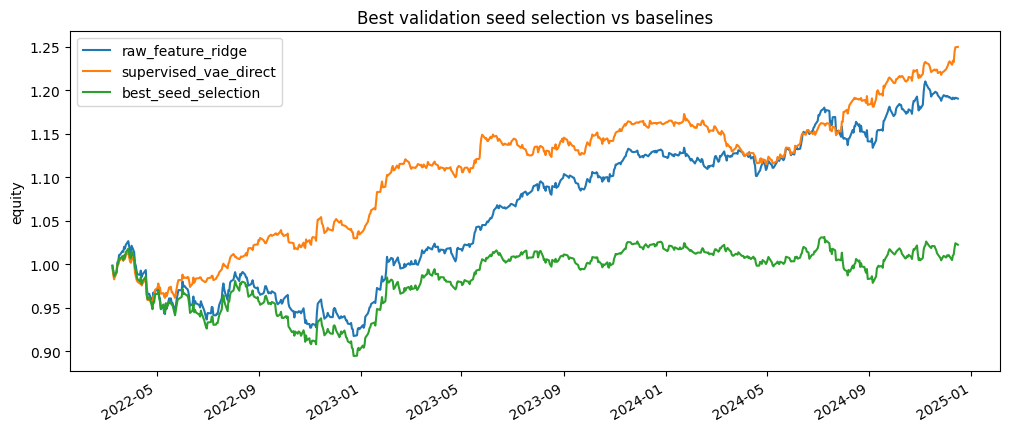

In [48]:
equity = (1 + comparison).cumprod()

equity.plot(
    figsize=(12, 5),
    title="Best validation seed selection vs baselines"
)

plt.ylabel("equity")
plt.show()

In [50]:
all_seed_returns = {}
all_seed_turnovers = {}
all_seed_stats = []

for r in results:
    seed = r["seed"]

    scores = predict_supervised_vae_scores(
        model=r["model"],
        X_input=X_valid[test_mask],
        y_mean=r["y_mean"],
        y_std=r["y_std"]
    )

    tmp_long = pd.DataFrame(
        {
            "date": dates_valid[test_mask],
            "ticker": tickers_valid[test_mask],
            "score": scores,
        }
    )

    tmp_wide = tmp_long.pivot(
        index="date",
        columns="ticker",
        values="score"
    ).sort_index()

    tmp_positions = build_rebalanced_positions_from_scores(
        tmp_wide,
        rebalance_every=10,
        long_q=0.8,
        short_q=0.2
    )

    tmp_returns, tmp_turnover = portfolio_returns_from_positions(
        tmp_positions,
        returns,
        transaction_cost=0.001
    )

    tmp_returns.name = f"seed_{seed}"

    stats = performance_stats(tmp_returns)

    all_seed_returns[f"seed_{seed}"] = tmp_returns
    all_seed_turnovers[f"seed_{seed}"] = tmp_turnover

    all_seed_stats.append(
        {
            "seed": seed,
            "test_sharpe": stats["sharpe"],
            "test_total_return": stats["total_return"],
            "test_max_drawdown": stats["max_drawdown"],
            "turnover": tmp_turnover.mean(),
        }
    )

all_seed_stats_df = pd.DataFrame(all_seed_stats)

all_seed_stats_df.sort_values(
    "test_sharpe",
    ascending=False
)

,seed,test_sharpe,test_total_return,test_max_drawdown,turnover
7,7,1.027233,0.179098,-0.081881,0.027125
1,1,1.020132,0.155733,-0.064745,0.040306
9,9,1.008332,0.162442,-0.060437,0.022159
8,8,0.862853,0.131306,-0.063110,0.038873
17,17,0.861091,0.173677,-0.103932,0.015377
16,16,0.719889,0.134938,-0.086681,0.024833
2,2,0.705177,0.117978,-0.069749,0.030946
4,4,0.698185,0.111464,-0.068383,0.035530
5,5,0.695986,0.117556,-0.072455,0.027316
18,18,0.684274,0.139093,-0.095223,0.016905


In [51]:
seed_analysis = results_df.merge(
    all_seed_stats_df,
    on="seed",
    how="inner"
)

seed_analysis.sort_values(
    "best_val_corr",
    ascending=False
)

,seed,best_val_corr,best_epoch,test_sharpe,test_total_return,test_max_drawdown,turnover
6,6,0.055239,0,0.120655,0.022462,-0.121171,0.012798
1,1,0.043383,8,1.020132,0.155733,-0.064745,0.040306
13,13,0.034374,8,0.145604,0.020977,-0.085610,0.038395
17,17,0.030245,0,0.861091,0.173677,-0.103932,0.015377
3,3,0.027691,2,0.553531,0.088291,-0.080572,0.029990
4,4,0.026325,5,0.698185,0.111464,-0.068383,0.035530
11,11,0.026248,3,0.661733,0.108601,-0.075368,0.032092
9,9,0.025339,0,1.008332,0.162442,-0.060437,0.022159
12,12,0.022827,8,-0.018503,-0.002568,-0.061950,0.037727
2,2,0.022773,2,0.705177,0.117978,-0.069749,0.030946


In [52]:
val_test_corr = seed_analysis["best_val_corr"].corr(
    seed_analysis["test_sharpe"]
)

val_test_corr

np.float64(-0.2725600734840509)

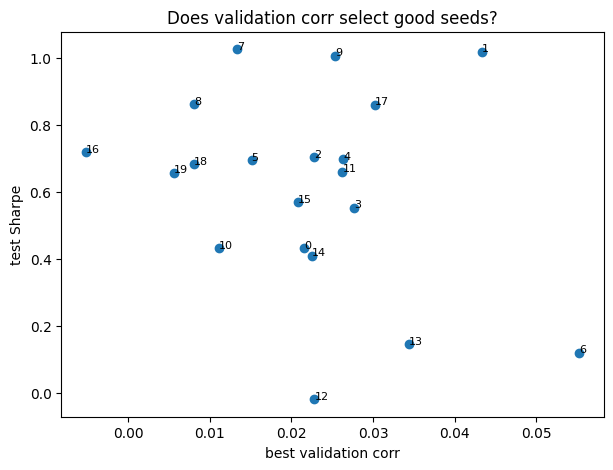

In [53]:
plt.figure(figsize=(7, 5))

plt.scatter(
    seed_analysis["best_val_corr"],
    seed_analysis["test_sharpe"]
)

for _, row in seed_analysis.iterrows():
    plt.text(
        row["best_val_corr"],
        row["test_sharpe"],
        str(int(row["seed"])),
        fontsize=8
    )

plt.xlabel("best validation corr")
plt.ylabel("test Sharpe")
plt.title("Does validation corr select good seeds?")
plt.show()

In [54]:
DATA_BACKTESTS.mkdir(
    parents=True,
    exist_ok=True
)

comparison.to_parquet(
    DATA_BACKTESTS
    / "best_seed_selection_returns.parquet"
)

comparison_stats.to_csv(
    DATA_BACKTESTS
    / "best_seed_selection_comparison_stats.csv"
)

seed_analysis.to_csv(
    DATA_BACKTESTS
    / "best_seed_selection_seed_analysis.csv",
    index=False
)

In [55]:
results_df.sort_values("best_val_corr", ascending=False).head(10)

,seed,best_val_corr,best_epoch
6,6,0.055239,0
1,1,0.043383,8
13,13,0.034374,8
17,17,0.030245,0
3,3,0.027691,2
4,4,0.026325,5
11,11,0.026248,3
9,9,0.025339,0
12,12,0.022827,8
2,2,0.022773,2


In [56]:
all_seed_stats_df.sort_values("test_sharpe", ascending=False).head(10)

,seed,test_sharpe,test_total_return,test_max_drawdown,turnover
7,7,1.027233,0.179098,-0.081881,0.027125
1,1,1.020132,0.155733,-0.064745,0.040306
9,9,1.008332,0.162442,-0.060437,0.022159
8,8,0.862853,0.131306,-0.063110,0.038873
17,17,0.861091,0.173677,-0.103932,0.015377
16,16,0.719889,0.134938,-0.086681,0.024833
2,2,0.705177,0.117978,-0.069749,0.030946
4,4,0.698185,0.111464,-0.068383,0.035530
5,5,0.695986,0.117556,-0.072455,0.027316
18,18,0.684274,0.139093,-0.095223,0.016905


In [57]:
seed_analysis.sort_values("best_val_corr", ascending=False).head(10)

,seed,best_val_corr,best_epoch,test_sharpe,test_total_return,test_max_drawdown,turnover
6,6,0.055239,0,0.120655,0.022462,-0.121171,0.012798
1,1,0.043383,8,1.020132,0.155733,-0.064745,0.040306
13,13,0.034374,8,0.145604,0.020977,-0.085610,0.038395
17,17,0.030245,0,0.861091,0.173677,-0.103932,0.015377
3,3,0.027691,2,0.553531,0.088291,-0.080572,0.029990
4,4,0.026325,5,0.698185,0.111464,-0.068383,0.035530
11,11,0.026248,3,0.661733,0.108601,-0.075368,0.032092
9,9,0.025339,0,1.008332,0.162442,-0.060437,0.022159
12,12,0.022827,8,-0.018503,-0.002568,-0.061950,0.037727
2,2,0.022773,2,0.705177,0.117978,-0.069749,0.030946


In [58]:
val_test_corr

np.float64(-0.2725600734840509)